## INFERENCE FILE FOR COLLAB USRES

In [1]:
!pip install -q segmentation-models-pytorch pycocotools

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 5.6 MB/s eta 0:00:00


In [2]:
import zipfile
zip_path = "/content/testing.zip"
extract_path = "/content/"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Files extracted to:", extract_path)

Files extracted to: /content/


✅ Calibration loaded
✅ Loaded state dict directly
✅ Model ready on cpu
✅ Found 4 images



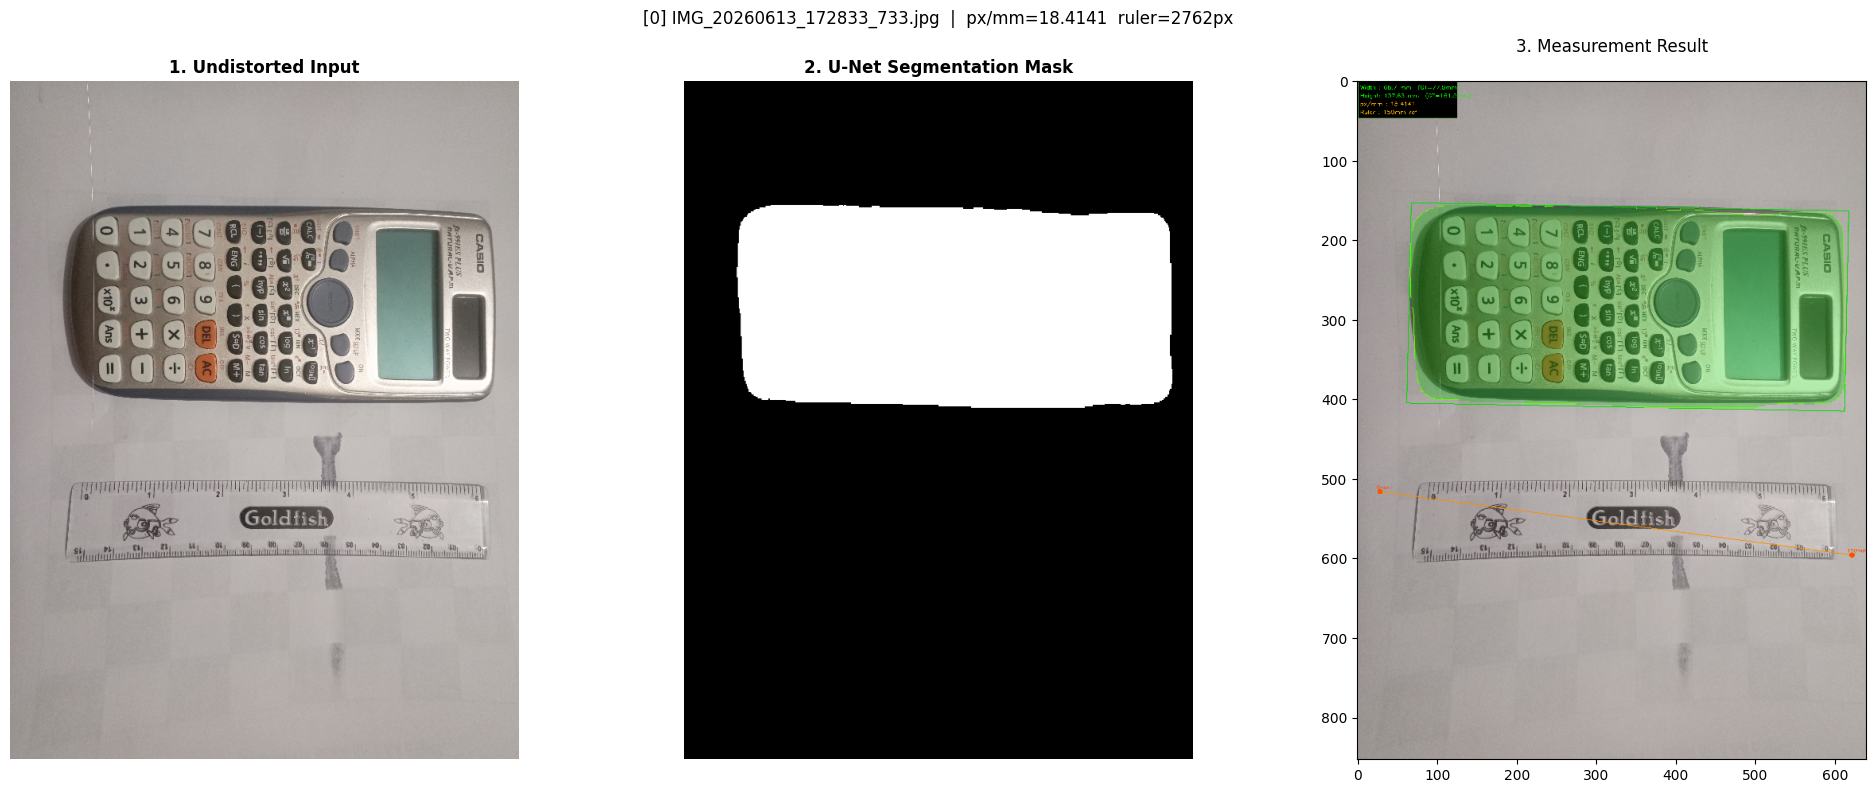

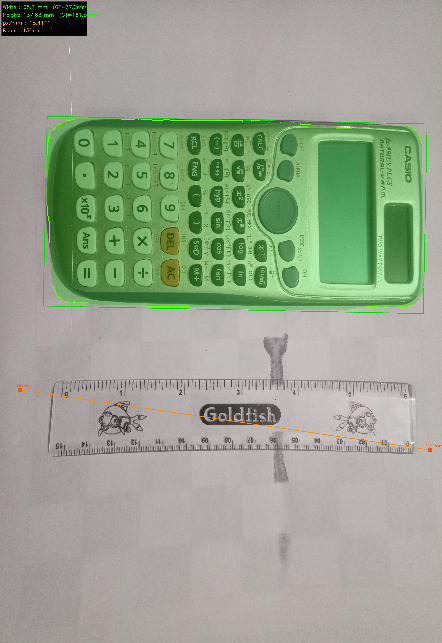

✅ [00] IMG_20260613_172833_733.jpg
   Width : 68.7 mm  GT=77.0  err=8.30mm  10.8%
   Height: 137.63 mm  GT=161.5  err=23.87mm  14.8%
   ruler : 2762.1px  px/mm=18.4141  mask_coverage=24.2%



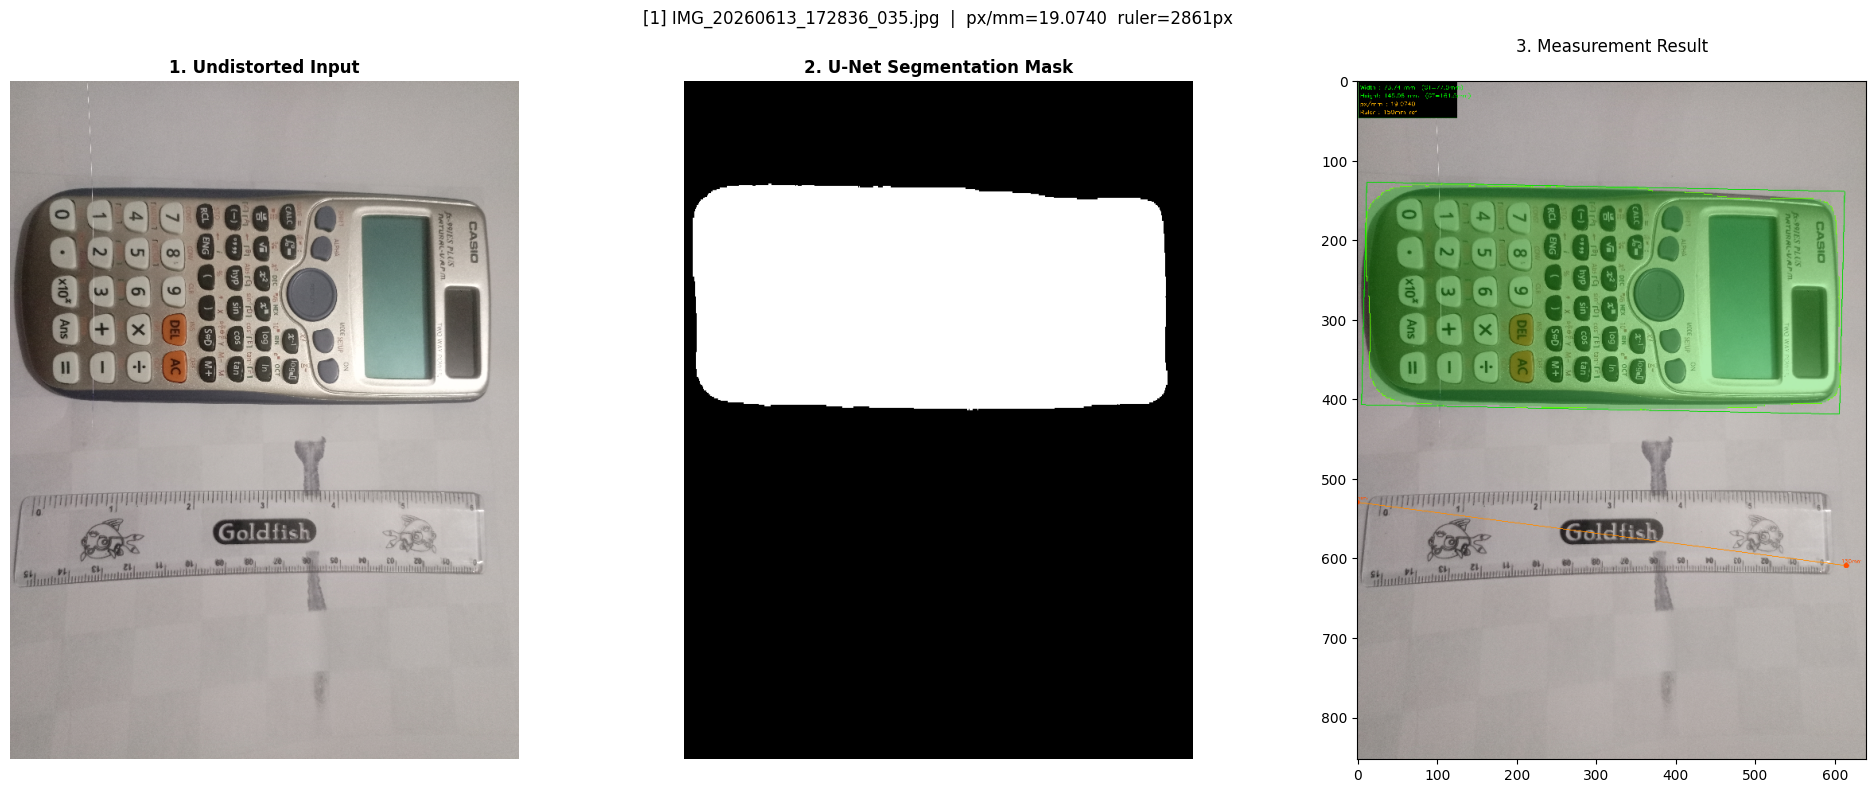

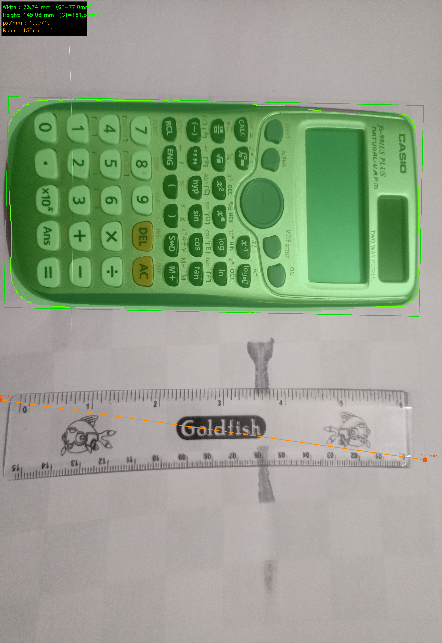

✅ [01] IMG_20260613_172836_035.jpg
   Width : 73.74 mm  GT=77.0  err=3.26mm  4.2%
   Height: 145.06 mm  GT=161.5  err=16.44mm  10.2%
   ruler : 2861.1px  px/mm=19.0740  mask_coverage=29.2%



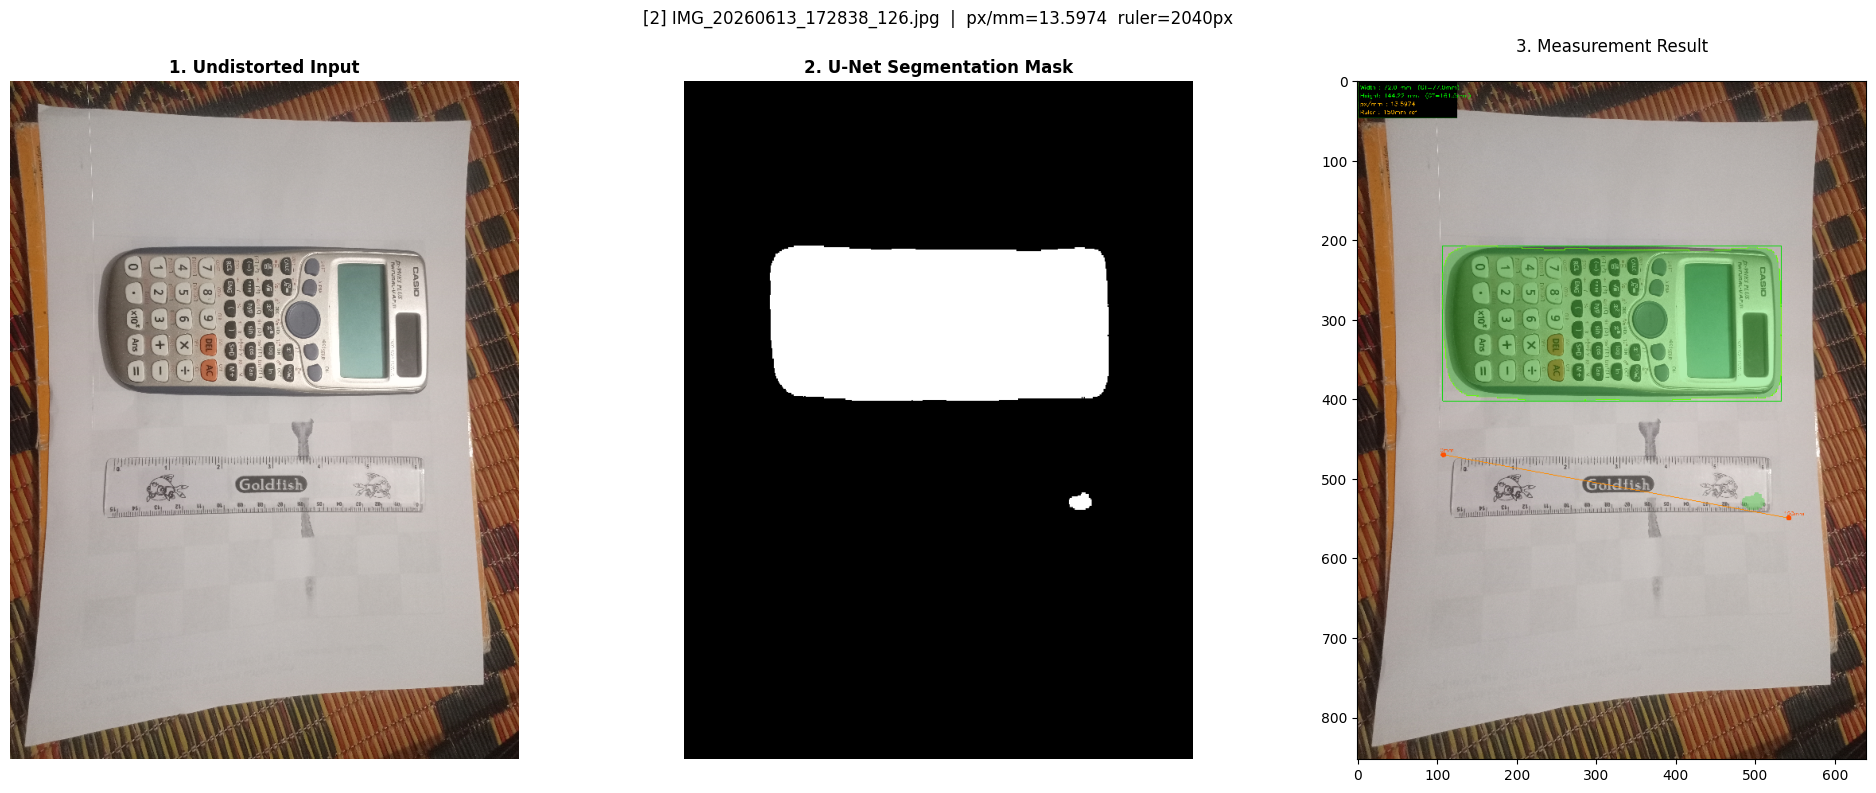

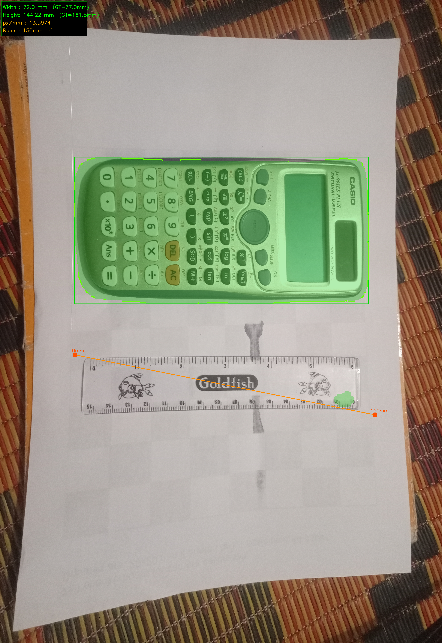

✅ [02] IMG_20260613_172838_126.jpg
   Width : 72.0 mm  GT=77.0  err=5.00mm  6.5%
   Height: 144.22 mm  GT=161.5  err=17.28mm  10.7%
   ruler : 2039.6px  px/mm=13.5974  mask_coverage=14.6%



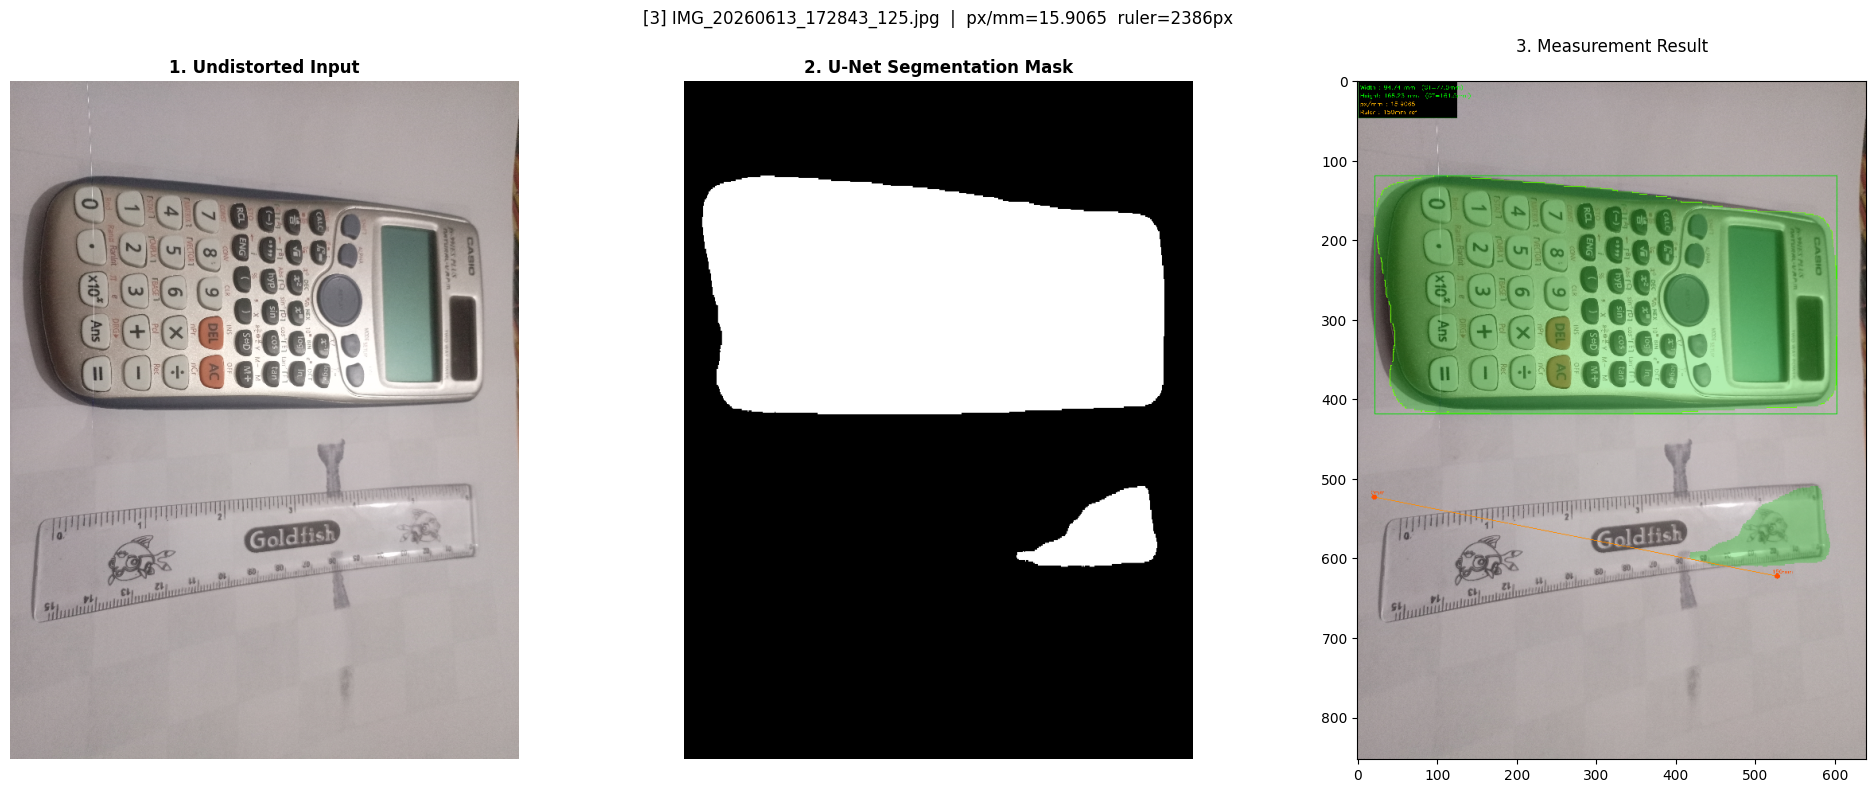

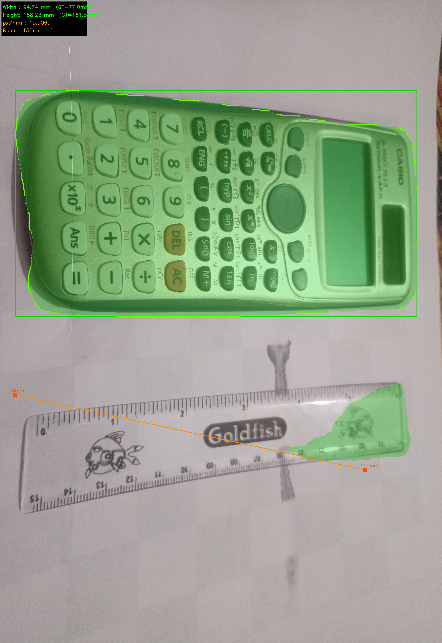

✅ [03] IMG_20260613_172843_125.jpg
   Width : 94.74 mm  GT=77.0  err=17.74mm  23.0%
   Height: 168.23 mm  GT=161.5  err=6.73mm  4.2%
   ruler : 2386.0px  px/mm=15.9065  mask_coverage=30.2%


           FINAL ACCURACY REPORT
  Images processed  : 4 / 4
  Images failed     : 0
  Ground Truth W    : 77.0 mm
  Ground Truth H    : 161.5 mm
------------------------------------------------------------
  MAE Width         : 8.57 mm
  MAE Height        : 16.08 mm
  MPE Width         : 11.13 %
  MPE Height        : 9.96 %
                      image  width_mm  height_mm  err_w_mm  err_h_mm  pct_err_w  pct_err_h
IMG_20260613_172833_733.jpg     68.70     137.63      8.30     23.87      10.78      14.78
IMG_20260613_172836_035.jpg     73.74     145.06      3.26     16.44       4.23      10.18
IMG_20260613_172838_126.jpg     72.00     144.22      5.00     17.28       6.49      10.70
IMG_20260613_172843_125.jpg     94.74     168.23     17.74      6.73      23.04       4.17


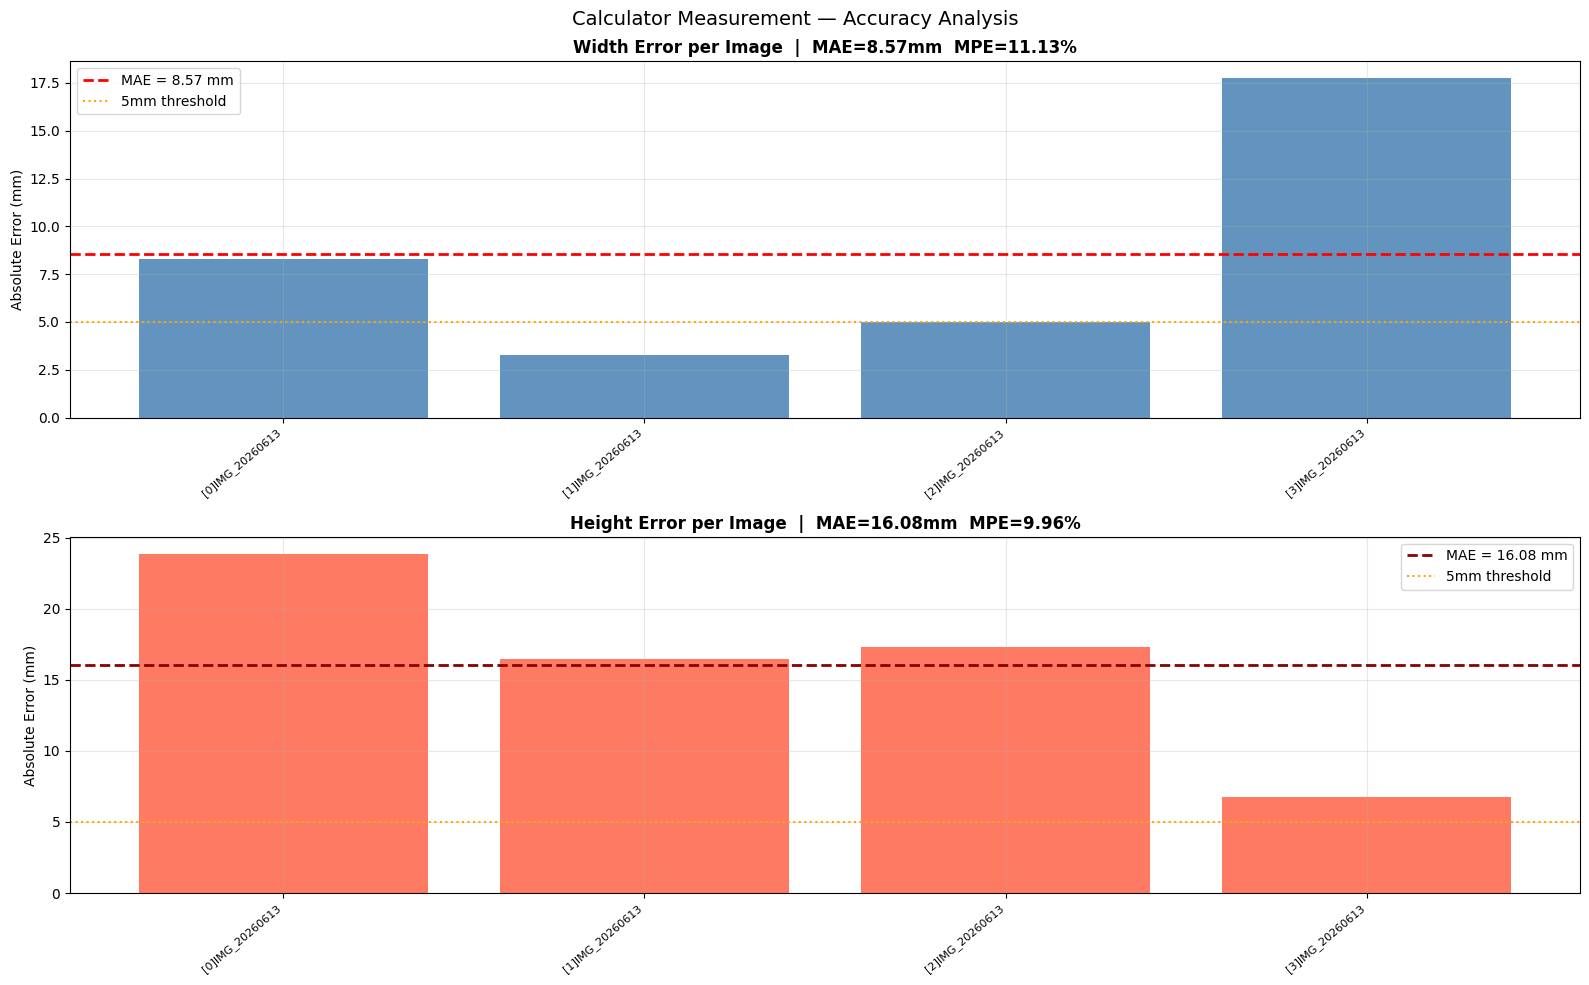


✅ CSV  : /content/outputs/measurement_report.csv
✅ Plot : /content/outputs/error_analysis.png
✅ All annotated images in: /content/outputs/


In [15]:


import os, cv2, torch, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import segmentation_models_pytorch as smp
from pathlib import Path
from google.colab.patches import cv2_imshow

REFERENCE_MM  = 150.0
GT_WIDTH_MM   = 77.0
GT_HEIGHT_MM  = 161.5
INPUT_SIZE    = 512
SHOW_SCALE    = 0.15
OUTPUT_DIR    = '/content/outputs'
IMAGE_DIR     = '/content/testing'
os.makedirs(OUTPUT_DIR, exist_ok=True)


RULER_COORDS = {
    0:  (20,  390, 430, 450),
    1:  (0,   400, 425, 460),
    2:  (75,  355, 375, 415),
    3:  (15,  395, 365, 470),
  }


camera_matrix = np.load('/content/new_camera_matrix.npy')
dist_coeffs   = np.load('/content/new_dist_coeffs.npy')
print("Calibration loaded")


device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = smp.Unet(encoder_name="resnet34", encoder_weights=None,
                 in_channels=3, classes=1, activation=None)
state = torch.load('/content/best_model.pth', map_location=device)
if isinstance(state, dict):
    try:
        model.load_state_dict(state)
        print("✅ Loaded state dict directly")
    except Exception as e:
        print(f"   state_dict failed ({e}), trying full model load...")
        model = torch.load('/content/best_model.pth', map_location=device)
else:
    model = state
model = model.to(device)
model.eval()
print(f"Model ready on {device}")

# ── HELPERS ──────────────────────────────────────────────────
def undistort_image(img):
    h, w = img.shape[:2]
    newmtx, roi = cv2.getOptimalNewCameraMatrix(
        camera_matrix, dist_coeffs, (w,h), 1, (w,h))
    dst = cv2.undistort(img, camera_matrix, dist_coeffs, None, newmtx)
    x, y, rw, rh = roi
    if rw > 10 and rh > 10:
        dst = dst[y:y+rh, x:x+rw]
    return dst

def get_mask(img_bgr):
    ih, iw = img_bgr.shape[:2]
    resized = cv2.resize(img_bgr, (INPUT_SIZE, INPUT_SIZE))
    rgb = cv2.cvtColor(resized, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    rgb  = (rgb - mean) / std
    t = torch.from_numpy(rgb).permute(2,0,1).float().unsqueeze(0).to(device)
    with torch.no_grad():
        out = model(t)
    if isinstance(out, (list, tuple)):
        out = out[0]
    mask = out.squeeze().cpu().numpy()
    if mask.min() < -0.5 or mask.max() > 1.5:
        mask = 1.0 / (1.0 + np.exp(-mask))
    mask = (mask > 0.5).astype(np.uint8) * 255
    return cv2.resize(mask, (iw, ih), interpolation=cv2.INTER_NEAREST)

def measure(mask, px_per_mm):
    k = np.ones((5,5), np.uint8)
    m = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, k)
    m = cv2.morphologyEx(m,    cv2.MORPH_OPEN,  k)
    cnts, _ = cv2.findContours(m, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts:
        return None
    c = max(cnts, key=cv2.contourArea)
    if cv2.contourArea(c) < 1000:
        return None
    rect   = cv2.minAreaRect(c)
    d1, d2 = rect[1]
    h_px   = max(d1, d2)
    w_px   = min(d1, d2)
    return {
        'w_mm'   : round(w_px / px_per_mm, 2),
        'h_mm'   : round(h_px / px_per_mm, 2),
        'w_px'   : round(w_px, 1),
        'h_px'   : round(h_px, 1),
        'rect'   : rect,
        'contour': c
    }

def build_annotated(undist, mask, meas, pt1, pt2, px_per_mm):
    ann = undist.copy()
    ov  = ann.copy()
    ov[mask > 0] = [0, 200, 0]
    ann = cv2.addWeighted(ann, 0.7, ov, 0.3, 0)
    box = cv2.boxPoints(meas['rect']).astype(int)
    cv2.drawContours(ann, [box], 0, (0, 220, 0), 3)
    cv2.drawContours(ann, [meas['contour']], -1, (0, 255, 100), 2)
    cv2.line(ann, pt1, pt2, (0, 140, 255), 4)
    cv2.circle(ann, pt1, 16, (0, 80, 255), -1)
    cv2.circle(ann, pt2, 16, (0, 80, 255), -1)
    cv2.putText(ann, "0mm",  (pt1[0]-20, pt1[1]-18),
                cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 80, 255), 2)
    cv2.putText(ann, f"{REFERENCE_MM:.0f}mm", (pt2[0]-30, pt2[1]-18),
                cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 80, 255), 2)
    # Black background box for text
    cv2.rectangle(ann, (8, 8), (580, 240), (0,0,0), -1)
    cv2.rectangle(ann, (8, 8), (580, 240), (0,220,0), 2)
    lines = [
        (f"Width : {meas['w_mm']} mm  (GT={GT_WIDTH_MM}mm)", (0,255,0)),
        (f"Height: {meas['h_mm']} mm  (GT={GT_HEIGHT_MM}mm)",(0,255,0)),
        (f"px/mm : {px_per_mm:.4f}",                          (0,180,255)),
        (f"Ruler : {REFERENCE_MM:.0f}mm ref",                 (0,180,255)),
    ]
    for i, (txt, col) in enumerate(lines):
        cv2.putText(ann, txt, (18, 58 + i*52),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.1, col, 2)
    return ann


all_images = sorted([
    p for ext in ['*.jpg','*.jpeg','*.png','*.JPG','*.JPEG','*.PNG']
    for p in Path(IMAGE_DIR).rglob(ext)
])
print(f"✅ Found {len(all_images)} images\n")


all_results = []
failed      = []

for idx, img_path in enumerate(all_images):
    fname = img_path.name

    if idx not in RULER_COORDS:
        print(f"⚠️  [{idx:02d}] {fname} — no coords, skipping")
        continue

    p1x, p1y, p2x, p2y = RULER_COORDS[idx]

    scale = 1.0 / SHOW_SCALE
    pt1 = (int(p1x * scale), int(p1y * scale))
    pt2 = (int(p2x * scale), int(p2y * scale))

    try:

        img    = cv2.imread(str(img_path))
        if img is None:
            raise ValueError("Cannot read image file")
        undist = undistort_image(img)
        h_u, w_u = undist.shape[:2]


        for pt, name in [(pt1,'P1'),(pt2,'P2')]:
            if not (0 <= pt[0] < w_u and 0 <= pt[1] < h_u):
                raise ValueError(
                    f"{name}={pt} is outside image {w_u}x{h_u} — fix coords for idx {idx}")


        ruler_px  = np.sqrt((pt2[0]-pt1[0])**2 + (pt2[1]-pt1[1])**2)
        if ruler_px < 50:
            raise ValueError(f"Ruler too short ({ruler_px:.0f}px) — coords may be wrong")
        px_per_mm = ruler_px / REFERENCE_MM

        # Segment
        mask     = get_mask(undist)
        coverage = (mask > 0).sum() / mask.size * 100

        # Measure
        meas = measure(mask, px_per_mm)
        if meas is None:
            raise ValueError(f"No calculator found in mask (coverage={coverage:.1f}%)")

        w_mm  = meas['w_mm']
        h_mm  = meas['h_mm']
        err_w = abs(w_mm - GT_WIDTH_MM)
        err_h = abs(h_mm - GT_HEIGHT_MM)
        pct_w = err_w / GT_WIDTH_MM  * 100
        pct_h = err_h / GT_HEIGHT_MM * 100

        # Annotate + save full res
        ann = build_annotated(undist, mask, meas, pt1, pt2, px_per_mm)
        cv2.imwrite(f'{OUTPUT_DIR}/{fname}', ann)

        # Save 3-panel figure for report
        fig, axes = plt.subplots(1, 3, figsize=(20, 8))
        axes[0].imshow(cv2.cvtColor(
            cv2.resize(undist,(640,853)), cv2.COLOR_BGR2RGB))
        axes[0].set_title('1. Undistorted Input', fontsize=12, fontweight='bold')
        axes[0].axis('off')

        mask_disp = cv2.resize(mask,(640,853))
        axes[1].imshow(mask_disp, cmap='gray')
        axes[1].set_title('2. U-Net Segmentation Mask', fontsize=12, fontweight='bold')
        axes[1].axis('off')

        axes[2].imshow(cv2.cvtColor(
            cv2.resize(ann,(640,853)), cv2.COLOR_BGR2RGB))
        axes[2].set_title(
            f'3. Measurement Result\n'
        )

        plt.suptitle(f'[{idx}] {fname}  |  px/mm={px_per_mm:.4f}  '
                     f'ruler={ruler_px:.0f}px', fontsize=12)
        plt.tight_layout()
        fig_path = f'{OUTPUT_DIR}/panel_{idx:02d}_{fname}.png'
        plt.savefig(fig_path, dpi=100, bbox_inches='tight')
        plt.show()
        plt.close()


        preview = cv2.resize(ann, (int(ann.shape[1]*SHOW_SCALE),
                                    int(ann.shape[0]*SHOW_SCALE)))
        cv2_imshow(preview)

        print(f"✅ [{idx:02d}] {fname}")
        print(f"   Width : {w_mm} mm  GT={GT_WIDTH_MM}  err={err_w:.2f}mm  {pct_w:.1f}%")
        print(f"   Height: {h_mm} mm  GT={GT_HEIGHT_MM}  err={err_h:.2f}mm  {pct_h:.1f}%")
        print(f"   ruler : {ruler_px:.1f}px  px/mm={px_per_mm:.4f}  "
              f"mask_coverage={coverage:.1f}%\n")

        all_results.append({
            'image'       : fname,
            'width_mm'    : w_mm,
            'height_mm'   : h_mm,
            'gt_width_mm' : GT_WIDTH_MM,
            'gt_height_mm': GT_HEIGHT_MM,
            'err_w_mm'    : round(err_w, 2),
            'err_h_mm'    : round(err_h, 2),
            'pct_err_w'   : round(pct_w, 2),
            'pct_err_h'   : round(pct_h, 2),
            'px_per_mm'   : round(px_per_mm, 4),
            'ruler_px'    : round(ruler_px, 1),
            'mask_coverage': round(coverage, 2),
        })

    except Exception as e:
        print(f" [{idx:02d}] {fname} — {e}\n")
        failed.append({'image': fname, 'error': str(e)})

# ── FINAL ACCURACY REPORT ────────────────────────────────────
print("\n" + "="*60)
print("           FINAL ACCURACY REPORT")
print("="*60)

if not all_results:
    print(" No successful results — check errors above")
else:
    df    = pd.DataFrame(all_results)
    mae_w = df['err_w_mm'].mean()
    mae_h = df['err_h_mm'].mean()
    mpe_w = df['pct_err_w'].mean()
    mpe_h = df['pct_err_h'].mean()

    print(f"  Images processed  : {len(df)} / {len(all_images)}")
    print(f"  Images failed     : {len(failed)}")
    print(f"  Ground Truth W    : {GT_WIDTH_MM} mm")
    print(f"  Ground Truth H    : {GT_HEIGHT_MM} mm")
    print("-"*60)
    print(f"  MAE Width         : {mae_w:.2f} mm")
    print(f"  MAE Height        : {mae_h:.2f} mm")
    print(f"  MPE Width         : {mpe_w:.2f} %")
    print(f"  MPE Height        : {mpe_h:.2f} %")
    print("="*60)
    print(df[['image','width_mm','height_mm',
              'err_w_mm','err_h_mm',
              'pct_err_w','pct_err_h']].to_string(index=False))

    # Save CSV
    df.to_csv(f'{OUTPUT_DIR}/measurement_report.csv', index=False)


    fig, axes = plt.subplots(2, 1, figsize=(16, 10))
    names  = [f"[{i}]{r['image'][:12]}" for i,r in enumerate(all_results)]
    x      = range(len(df))

    axes[0].bar(x, df['err_w_mm'], color='steelblue', alpha=0.85)
    axes[0].axhline(mae_w, color='red', linestyle='--', linewidth=2,
                    label=f'MAE = {mae_w:.2f} mm')
    axes[0].axhline(5.0, color='orange', linestyle=':', linewidth=1.5,
                    label='5mm threshold')
    axes[0].set_xticks(list(x))
    axes[0].set_xticklabels(names, rotation=40, ha='right', fontsize=8)
    axes[0].set_ylabel('Absolute Error (mm)')
    axes[0].set_title(f'Width Error per Image  |  MAE={mae_w:.2f}mm  MPE={mpe_w:.2f}%',
                      fontsize=12, fontweight='bold')
    axes[0].legend(fontsize=10)
    axes[0].grid(True, alpha=0.3)

    axes[1].bar(x, df['err_h_mm'], color='tomato', alpha=0.85)
    axes[1].axhline(mae_h, color='darkred', linestyle='--', linewidth=2,
                    label=f'MAE = {mae_h:.2f} mm')
    axes[1].axhline(5.0, color='orange', linestyle=':', linewidth=1.5,
                    label='5mm threshold')
    axes[1].set_xticks(list(x))
    axes[1].set_xticklabels(names, rotation=40, ha='right', fontsize=8)
    axes[1].set_ylabel('Absolute Error (mm)')
    axes[1].set_title(f'Height Error per Image  |  MAE={mae_h:.2f}mm  MPE={mpe_h:.2f}%',
                      fontsize=12, fontweight='bold')
    axes[1].legend(fontsize=10)
    axes[1].grid(True, alpha=0.3)

    plt.suptitle('Calculator Measurement — Accuracy Analysis', fontsize=14)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/error_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()

if failed:
    print(f"\n Failed images:")
    for f in failed:
        print(f"   {f['image']} — {f['error']}")
    print("\nFix: Check RULER_COORDS for those indices")
    print("     Coordinates must be inside the display image bounds")